# 1. Importing Required Libraries and Loading Dataset
"Sentiment and Emotion Analysis of Emirates Airline Reviews Using AI Techniques"

In [23]:
# 1. Importing Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# 2. Load Dataset
file_path = "D:/Westford/Westford Masters/Dissertation/dataset/emirates_reviews.csv"
df = pd.read_csv(file_path)
print(df.head()) # Display the first few rows of the DataFrame
df.columns.tolist()# Display the column names
print("Shape of the DataFrame:", df.shape) # Display the shapes of dataframe
print("Data types of each column:\n", df.dtypes) # Display the data types of each column
print("Summary statistics of the DataFrame:\n", df.describe()) # Display summary statistics of the DataFrame
print("Missing values per column:\n", df.isnull().sum()) # Display the number of missing values in each column
print("\nNumber of duplicate rows:", df.duplicated().sum()) # Display the number of duplicate rows


                                       Title    Date Published         Status  \
0                "upgrade to business class"  12th August 2024  Trip Verified   
1            "14 hour horrendous experience"  11th August 2024  Trip Verified   
2  "not welcome and passengers are a burden"    29th July 2024   Not Verified   
3     "should be considered among the worst"    18th July 2024  Trip Verified   
4                  “services are very great”    13th July 2024   Not Verified   

         Aircraft     Travel Type    Travel Class  \
0      Boeing 777    Solo Leisure  Business Class   
1             NaN  Couple Leisure   Economy Class   
2  Boeing 777-300    Solo Leisure   Economy Class   
3            A380        Business   Economy Class   
4            A380  Family Leisure   Economy Class   

                               Route Date Flown  Seating Comfort  \
0                    Dubai to Lisbon     Aug 24              5.0   
1          Delhi to Boston via Dubai     Aug 24           

2. EDA and Inital Data Exploration 

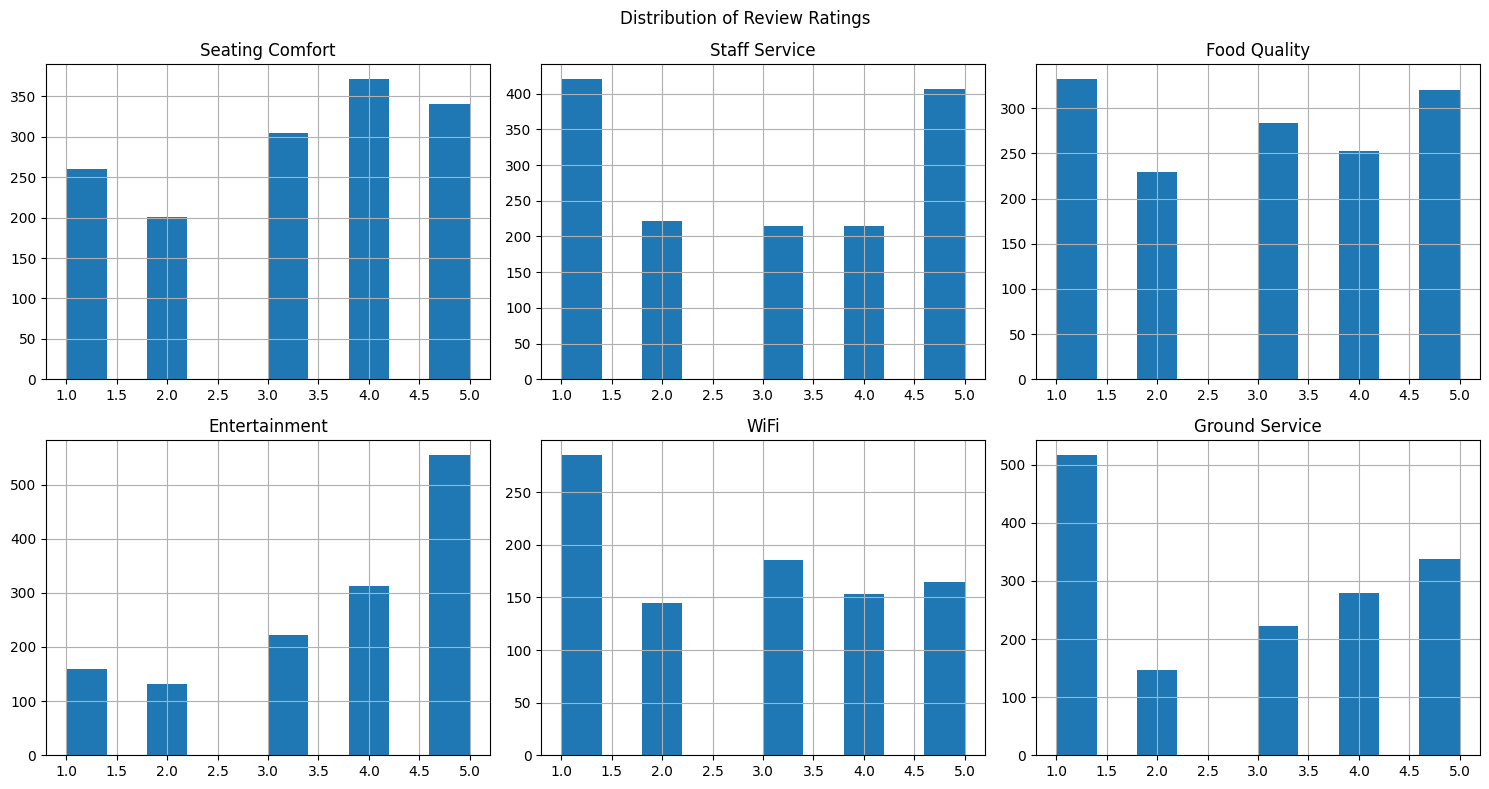

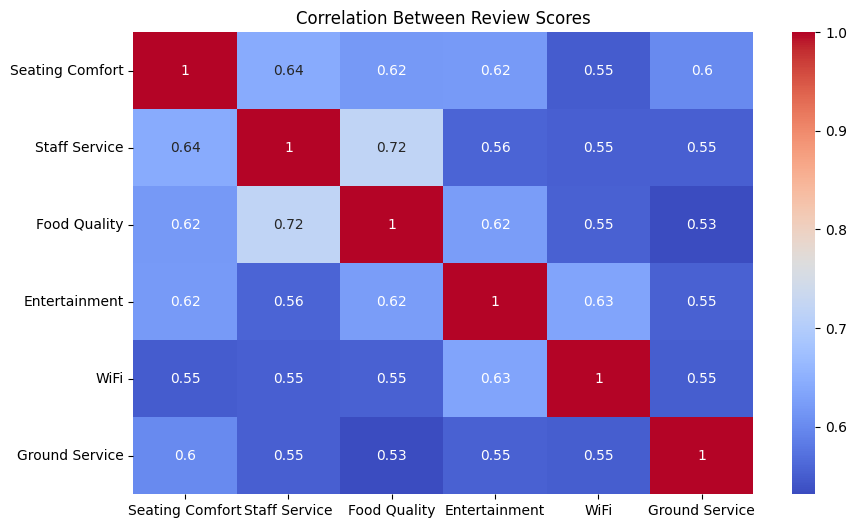

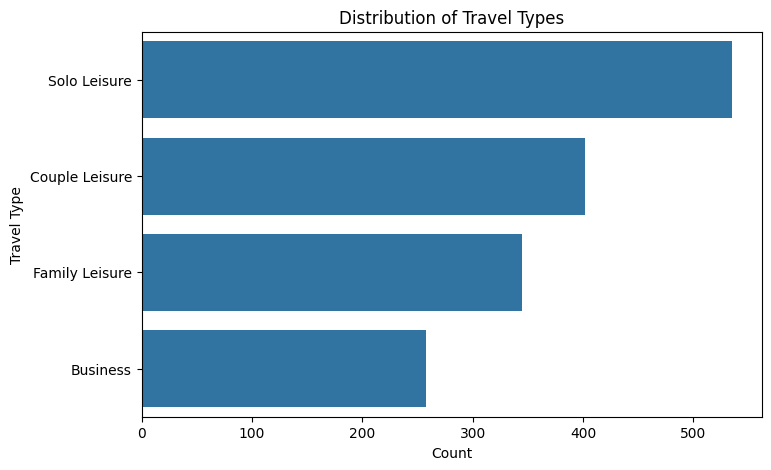

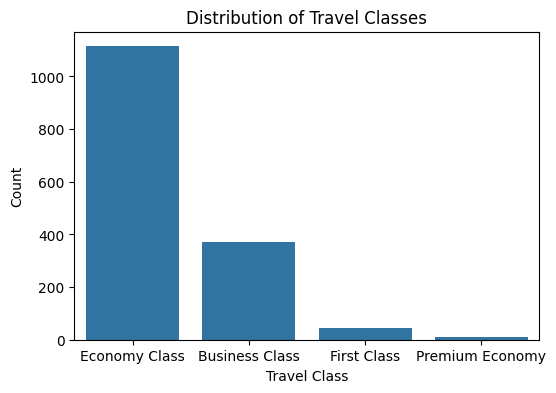

C:\Users\Fadi\AppData\Local\Temp\ipykernel_2764\906221665.py:28: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





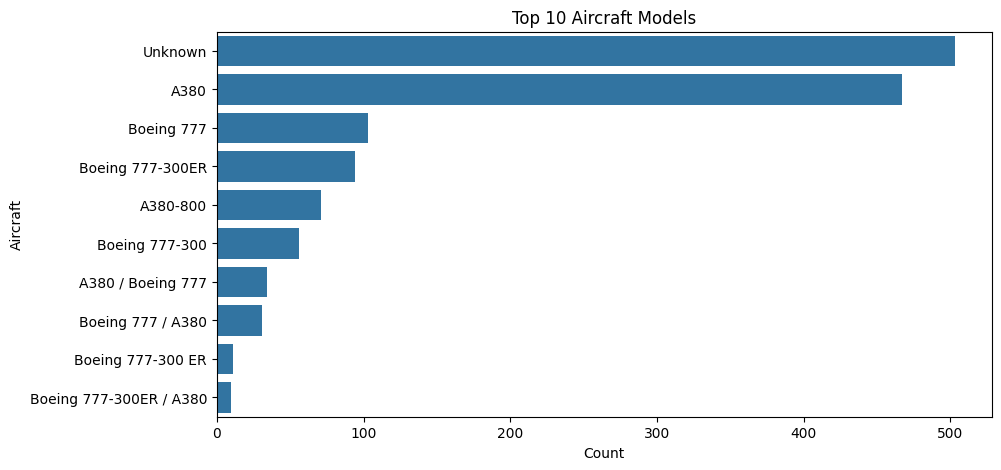

In [24]:
# 3. Exploratory Data Analysis (EDA)
rating_cols = ['Seating Comfort', 'Staff Service', 'Food Quality', 'Entertainment', 'WiFi', 'Ground Service']
df[rating_cols].hist(bins=10, figsize=(15, 8), layout=(2, 3))
plt.suptitle("Distribution of Review Ratings")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(df[rating_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Review Scores")
plt.show()

# Most Common Travel Types, Classes, Routes
plt.figure(figsize=(8, 5))
sns.countplot(data=df, y='Travel Type', order=df['Travel Type'].value_counts().index)
plt.title("Distribution of Travel Types")
plt.xlabel("Count")
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Travel Class', order=df['Travel Class'].value_counts().index)
plt.title("Distribution of Travel Classes")
plt.xlabel("Travel Class")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(10, 5))
df['Aircraft'].fillna("Unknown", inplace=True)
sns.countplot(data=df, y='Aircraft', order=df['Aircraft'].value_counts().head(10).index)
plt.title("Top 10 Aircraft Models")
plt.xlabel("Count")
plt.show()

# 3. Word Cloud of Review Titles

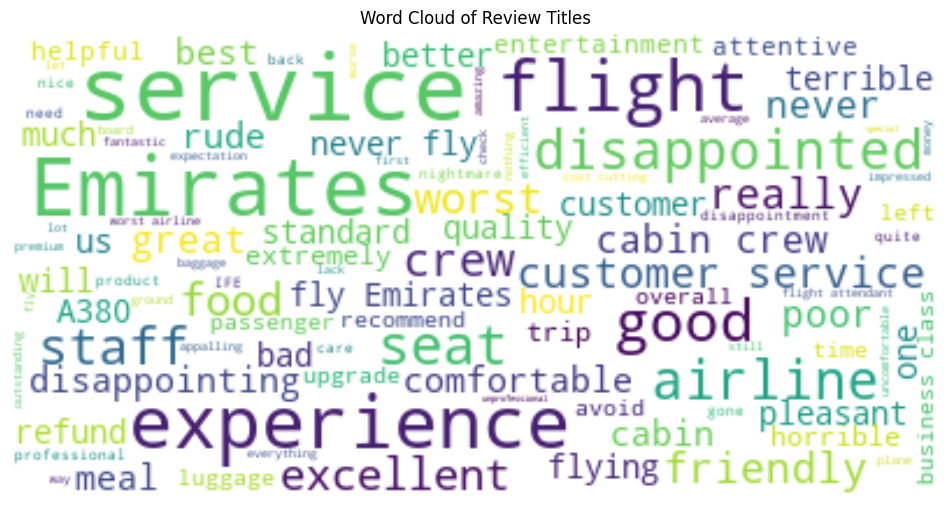

In [25]:
from wordcloud import WordCloud, STOPWORDS # Generate a word cloud for review titles
text = " ".join(df['Title'].astype(str))
wordcloud = WordCloud(stopwords=STOPWORDS, background_color='white', max_words=100, max_font_size=40, random_state=42).generate(text)
plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Review Titles")
plt.show()

4. Sentiment Labelling

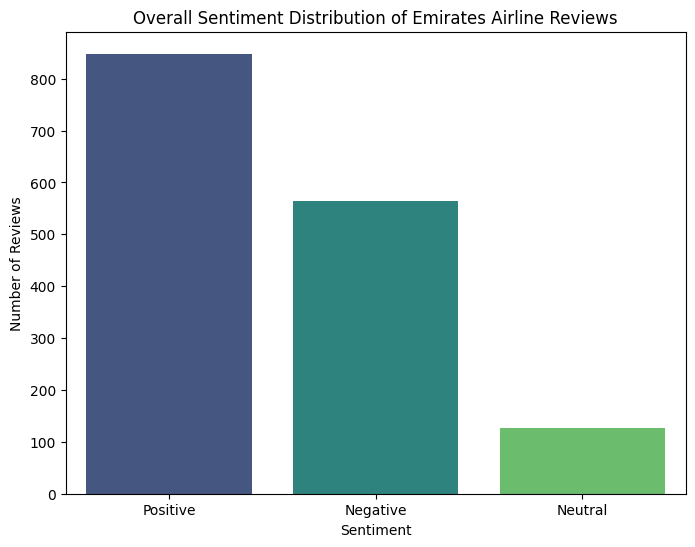

In [26]:
# 5. Sentiment Labeling
def rating_to_sentiment(rating): # Convert numerical ratings to sentiment labels
    if rating >= 4:
        return 'Positive'
    elif rating <= 2:
        return 'Negative'
    else:
        return 'Neutral'

df['Sentiment'] = df['Overall Rating'].apply(rating_to_sentiment)

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Sentiment', hue='Sentiment', palette='viridis')
plt.title('Overall Sentiment Distribution of Emirates Airline Reviews')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

5. Text Cleaning and Processing

In [27]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return ' '.join(words)

df['Cleaned_Review'] = df['Review'].apply(clean_text)
print(df[['Review', 'Cleaned_Review']].head(3))


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Fadi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Fadi\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


                                              Review  \
0     I flew a return trip DXB-LIS-DXB I used my ...   
1     We were 2 people travelling together and on...   
2     First time flying Emirates, was expecting a...   

                                      Cleaned_Review  
0  flew return trip dxblisdxb used mile upgrade b...  
1  people travelling together dubaiboston sector ...  
2  first time flying emirate expecting lot airlin...  


Topic 1: flight, seat, dubai, emirate, food, crew, service, good, cabin, meal
Topic 2: flight, dubai, emirate, service, class, business, airline, crew, staff, wheelchair
Topic 3: flight, emirate, dubai, hour, seat, time, staff, airport, airline, customer
Topic 4: dubai, emirate, luggage, bag, airport, boarding, gate, time, passenger, flight
Topic 5: emirate, service, airline, customer, flight, staff, dubai, ticket, business, year
Topic 1: flight, service, emirate, crew, food, dubai, seat, meal
Topic 2: seat, emirate, business, class, flight, dubai, business class, airline
Topic 3: bag, emirate, dubai, staff, luggage, baggage, gate, airport
Topic 4: customer, service, emirate, customer service, refund, flight, day, ticket
Topic 5: ticket, emirate, flight, airline, got, wheelchair, change, fly
Topic 6: flight, hour, emirate, dubai, airport, staff, long, hotel
Topic 7: flight, emirate, hour, dubai, airport, time, plane, delayed
Topic 8: flight, emirate, dubai, airline, time, service, hour

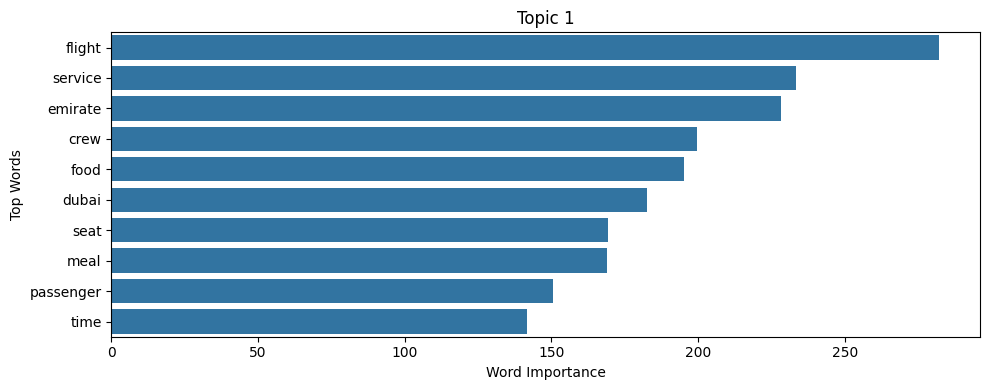

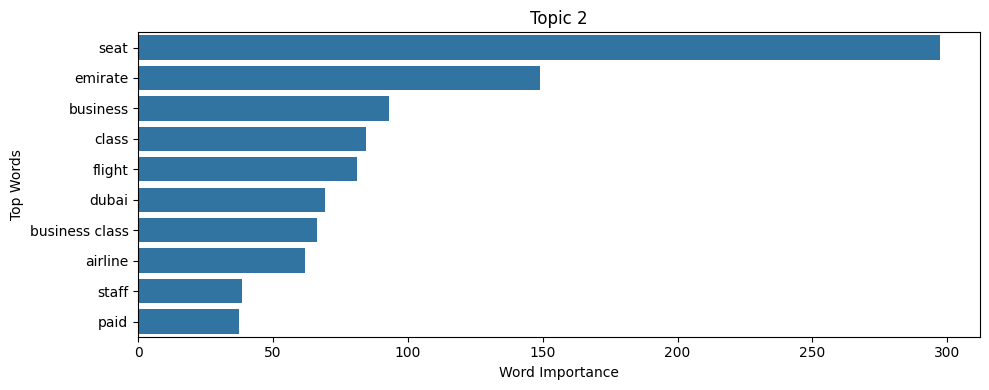

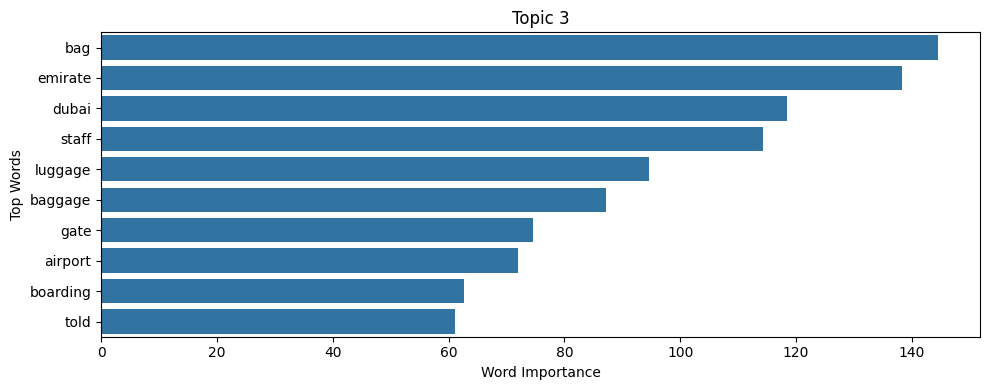

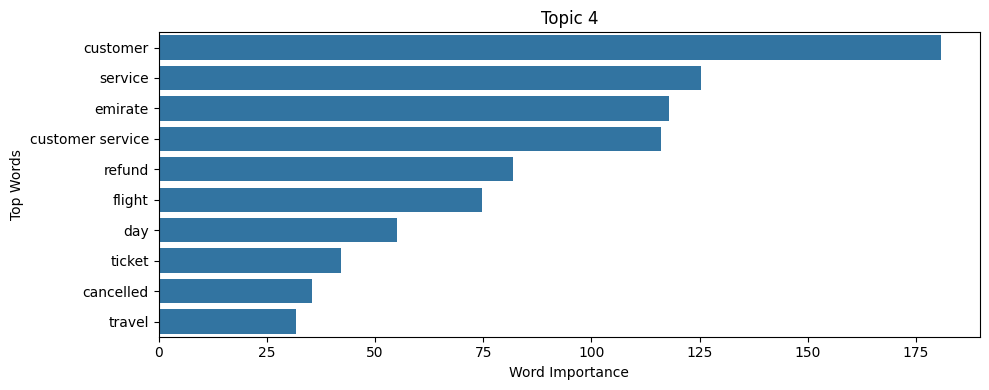

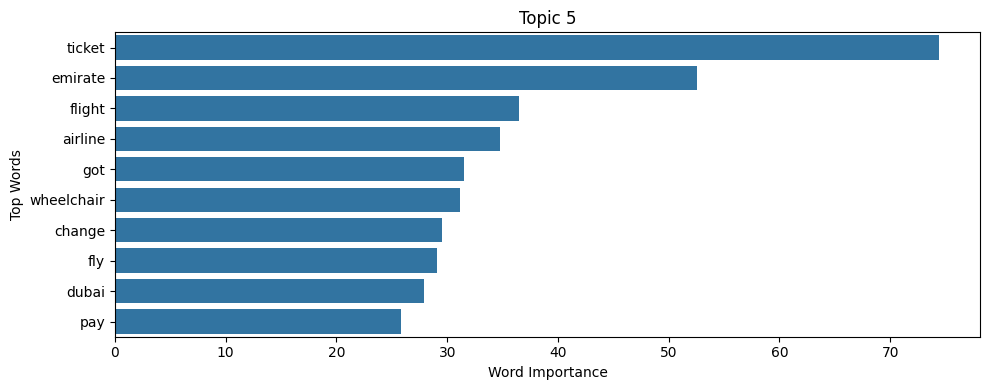

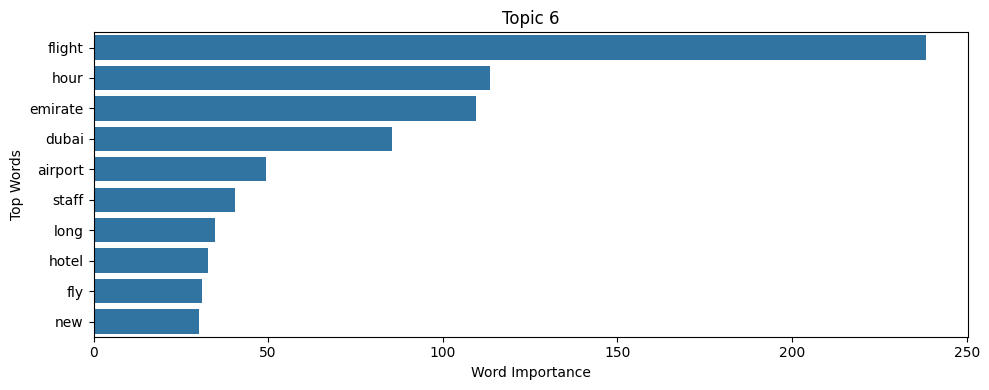

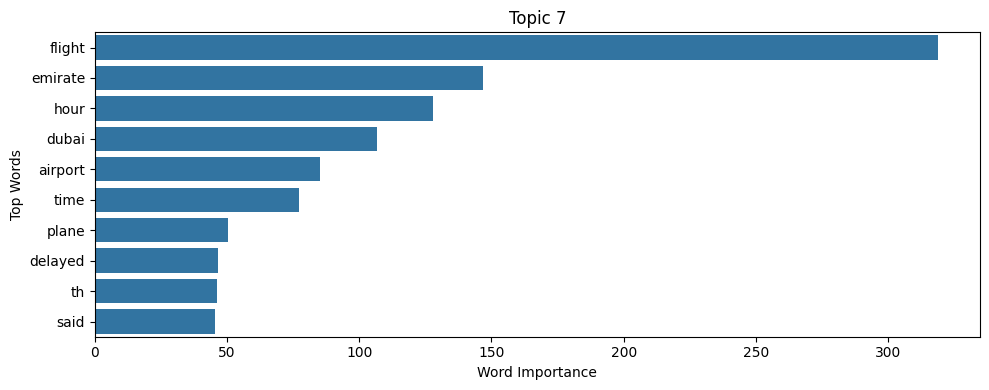

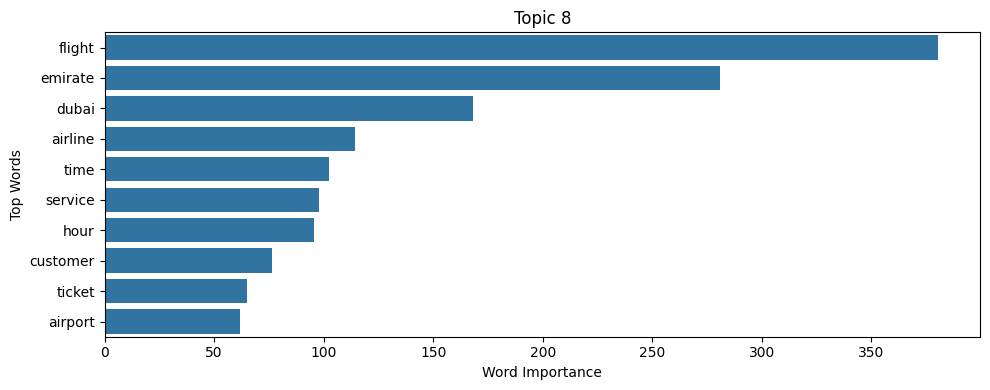

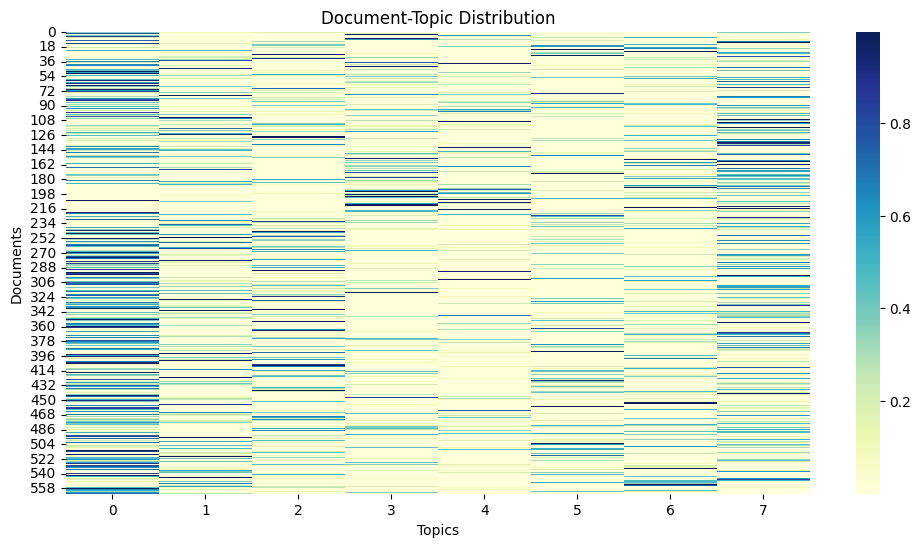

In [28]:

from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

# 1. Prepare Text Data
# Use cleaned reviews for topic modeling
reviews = df['Cleaned_Review'].dropna()

# Vectorize text using CountVectorizer
count_vectorizer = CountVectorizer(max_df=0.9, min_df=5, stop_words='english')
count_data = count_vectorizer.fit_transform(reviews)
feature_names = count_vectorizer.get_feature_names_out()

# 2. Train LDA Model
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(count_data)

# 3. Display Top Words per Topic
def display_topics(model, feature_names, no_top_words):
    for idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]
        print(f"Topic {idx+1}: {', '.join(top_words)}")

display_topics(lda, feature_names, 10)

# Filter negative reviews
negative_reviews = df[df['Sentiment'] == 'Negative']['Cleaned_Review'].dropna()

# Vectorize with n-grams
count_vectorizer = CountVectorizer(ngram_range=(1, 3), max_df=0.9, min_df=5, stop_words='english')
count_data = count_vectorizer.fit_transform(negative_reviews)
feature_names = count_vectorizer.get_feature_names_out()

# Train LDA
K = 8
lda_model = LatentDirichletAllocation(n_components=K, random_state=42, learning_method='batch', max_iter=20)
lda_model.fit(count_data)

# Display topics
display_topics(lda_model, feature_names, 8)
# 4. Visualize Topics
import matplotlib.pyplot as plt
import seaborn as sns

def plot_top_words(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[:-n_top_words - 1:-1]
        top_words = [feature_names[i] for i in top_indices]
        top_weights = topic[top_indices]

        plt.figure(figsize=(10, 4))
        sns.barplot(x=top_weights, y=top_words)
        plt.title(f"Topic {topic_idx + 1}")
        plt.xlabel("Word Importance")
        plt.ylabel("Top Words")
        plt.tight_layout()
        plt.show()
plot_top_words(lda_model, feature_names, n_top_words=10)


import numpy as np

doc_topic_dist = lda_model.transform(count_data)

plt.figure(figsize=(12, 6))
sns.heatmap(doc_topic_dist, cmap="YlGnBu", cbar=True)
plt.title("Document-Topic Distribution")
plt.xlabel("Topics")
plt.ylabel("Documents")
plt.show()


6. Feature Extraction (TF-IDF)

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

# The addition of ngram_range=(1, 3) creates features for single words (unigrams),
# two-word phrases (bigrams), and three-word phrases (trigrams).
# This is necessary to capture sentiment context (e.g., "not good" vs "good").

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 3)) 
X = tfidf.fit_transform(df['Cleaned_Review'])
X_array = X.toarray()

print("TF-IDF matrix shape (with N-grams):", X_array.shape)

TF-IDF matrix shape (with N-grams): (1540, 5000)


7. Train-Test Split

In [30]:
from sklearn.model_selection import train_test_split # Train-test split for model training and evaluation
y = df['Sentiment'] # Extract sentiment labels
X_train, X_test, y_train, y_test = train_test_split(X_array, y, test_size=0.2, random_state=42, stratify=y) # Train-test split
print(y.value_counts())

Sentiment
Positive    848
Negative    565
Neutral     127
Name: count, dtype: int64


8. Model Training and Evaluation


Logistic Regression Results:
Confusion Matrix:
 [[ 95   0  18]
 [ 12   0  13]
 [ 16   0 154]]

Classification Report:
               precision    recall  f1-score   support

    Negative       0.77      0.84      0.81       113
     Neutral       0.00      0.00      0.00        25
    Positive       0.83      0.91      0.87       170

    accuracy                           0.81       308
   macro avg       0.53      0.58      0.56       308
weighted avg       0.74      0.81      0.77       308



c:\Users\Fadi\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\Fadi\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\Fadi\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.




Random Forest Results:
Confusion Matrix:
 [[ 87   0  26]
 [ 13   1  11]
 [ 20   0 150]]

Classification Report:
               precision    recall  f1-score   support

    Negative       0.72      0.77      0.75       113
     Neutral       1.00      0.04      0.08        25
    Positive       0.80      0.88      0.84       170

    accuracy                           0.77       308
   macro avg       0.84      0.56      0.55       308
weighted avg       0.79      0.77      0.74       308


Naive Bayes Results:
Confusion Matrix:
 [[ 85   0  28]
 [ 15   0  10]
 [ 15   0 155]]

Classification Report:
               precision    recall  f1-score   support

    Negative       0.74      0.75      0.75       113
     Neutral       0.00      0.00      0.00        25
    Positive       0.80      0.91      0.85       170

    accuracy                           0.78       308
   macro avg       0.51      0.55      0.53       308
weighted avg       0.71      0.78      0.74       308


SVM Results

c:\Users\Fadi\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\Fadi\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\Fadi\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



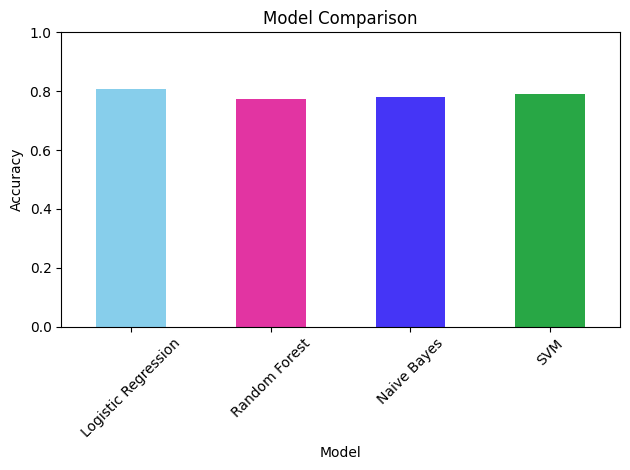

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

models = {
    'Logistic Regression': LogisticRegression(max_iter=200),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Naive Bayes': MultinomialNB(),
    'SVM': LinearSVC()
}

results = []
for name, clf in models.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append({'Model': name, 'Accuracy': acc})
    print(f"\n{name} Results:")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

results_df = pd.DataFrame(results)
colors = ['skyblue', "#e234a2", "#4535f6", "#28a745"]
results_df.plot(kind='bar', x='Model', y='Accuracy', legend=False, color=colors)
plt.title('Model Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


9. Binary Sentiment Model (Positive/Negative Only)

In [32]:
df_binary = df[df['Sentiment'] != 'Neutral']
X_binary = tfidf.transform(df_binary['Cleaned_Review']).toarray()
y_binary = df_binary['Sentiment']
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_binary, y_binary, test_size=0.2, random_state=42, stratify=y_binary)

log_model_b = LogisticRegression(max_iter=200, solver='liblinear')
log_model_b.fit(X_train_b, y_train_b)
y_pred_b = log_model_b.predict(X_test_b)
print("Confusion Matrix:\n", confusion_matrix(y_test_b, y_pred_b))
print("\nClassification Report:\n", classification_report(y_test_b, y_pred_b))
print("Accuracy Score:", accuracy_score(y_test_b, y_pred_b))


Confusion Matrix:
 [[ 87  26]
 [ 19 151]]

Classification Report:
               precision    recall  f1-score   support

    Negative       0.82      0.77      0.79       113
    Positive       0.85      0.89      0.87       170

    accuracy                           0.84       283
   macro avg       0.84      0.83      0.83       283
weighted avg       0.84      0.84      0.84       283

Accuracy Score: 0.8409893992932862


In [33]:
# START: HYPERPARAMETER TUNING CELL
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    'penalty': ['l1', 'l2'],
    'C': [0.01, 0.1, 1, 10, 50, 100],  # Test a wider range of regularization strengths
    'solver': ['liblinear'] 
}

log_reg = LogisticRegression(max_iter=200, random_state=42)

grid_search = GridSearchCV(
    estimator=log_reg, 
    param_grid=param_grid, 
    cv=5, 
    scoring='accuracy', 
    verbose=1, 
    n_jobs=-1
)

print("Starting Grid Search for Optimal Hyperparameters...")
grid_search.fit(X_train_b, y_train_b)

print("\nOptimal Parameters Found:")
print(grid_search.best_params_)

# Define the final optimized model variable
log_model_b_optimized = grid_search.best_estimator_

print(f"Best cross-validated training score: {grid_search.best_score_:.4f}")
# END: HYPERPARAMETER TUNING CELL
# ----------------------------------------------------------------------------------


# ----------------------------------------------------------------------------------
# START: UPDATED FINAL EVALUATION CELL (REPLACE OLD FIT)
# DELETE the original two lines below:
# log_model_b = LogisticRegression(max_iter=200, solver='liblinear')
# log_model_b.fit(X_train_b, y_train_b)

# Now, use the optimized model from the tuning step:
y_pred_b = log_model_b_optimized.predict(X_test_b) # Use the optimized model
print("Confusion Matrix:\n", confusion_matrix(y_test_b, y_pred_b))
print("\nClassification Report:\n", classification_report(y_test_b, y_pred_b))
print("Accuracy Score:", accuracy_score(y_test_b, y_pred_b))
# END: UPDATED FINAL EVALUATION CELL
# ----------------------------------------------------------------------------------

Starting Grid Search for Optimal Hyperparameters...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Optimal Parameters Found:
{'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
Best cross-validated training score: 0.8407
Confusion Matrix:
 [[ 95  18]
 [ 24 146]]

Classification Report:
               precision    recall  f1-score   support

    Negative       0.80      0.84      0.82       113
    Positive       0.89      0.86      0.87       170

    accuracy                           0.85       283
   macro avg       0.84      0.85      0.85       283
weighted avg       0.85      0.85      0.85       283

Accuracy Score: 0.8515901060070671


--- 1. Classification Report (Metrics) ---
              precision    recall  f1-score   support

    Negative       0.80      0.84      0.82       113
    Positive       0.89      0.86      0.87       170

    accuracy                           0.85       283
   macro avg       0.84      0.85      0.85       283
weighted avg       0.85      0.85      0.85       283



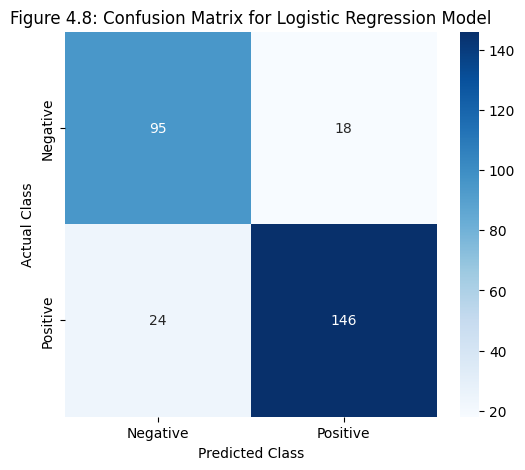

In [34]:
# --- START CELL 1: MODEL EVALUATION (Chapter 4.4) ---
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Predict on the test set
# Use the trained binary logistic regression model and binary test set
y_pred = log_model_b_optimized.predict(X_test_b)  # <--- UPDATED
y_proba = log_model_b_optimized.predict_proba(X_test_b)[:, 1] # <--- UPDATED

# 2. Classification Report (Metrics for Table 4.1)
print("--- 1. Classification Report (Metrics) ---")
print(classification_report(y_test_b, y_pred, target_names=['Negative', 'Positive']))

# 3. Confusion Matrix (Figure 4.8)
# IMPORTANT: The variable here should be y_pred (calculated above), not y_pred_b 
# (which was defined in a previous block and is now outdated)
cm = confusion_matrix(y_test_b, y_pred) 
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
			xticklabels=['Negative', 'Positive'], 
			yticklabels=['Negative', 'Positive'])
plt.title('Figure 4.8: Confusion Matrix for Logistic Regression Model')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.savefig('confusion_matrix.png')
plt.show()

# --- END CELL 1 ---

Word Cloud of Negative Sentiment Drives


--- 2. Top 20 Positive Sentiment Features ---
            feature  coefficient
2227           good     2.588956
1648      excellent     2.058515
1022           crew     1.695690
2111       friendly     1.675570
2271          great     1.657629
863     comfortable     1.530357
1575  entertainment     1.484627
2796         lounge     1.254561
2027           food     1.225808
2474            ife     1.161442
81         aircraft     1.095004
3304        overall     1.072785
172         amazing     1.039497
1426      efficient     1.015373
3132           nice     0.976446
3573   professional     0.924073
327       attentive     0.918231
3667         really     0.910756
4876           wifi     0.908005
596           cabin     0.891889

--- 3. Top 20 Negative Sentiment Features ---
               feature  coefficient
1067          customer    -2.107797
3082             never    -1.607187
4529              told    -1.425060
4424          terrible    -1.375103
1072  customer service    -1.3501

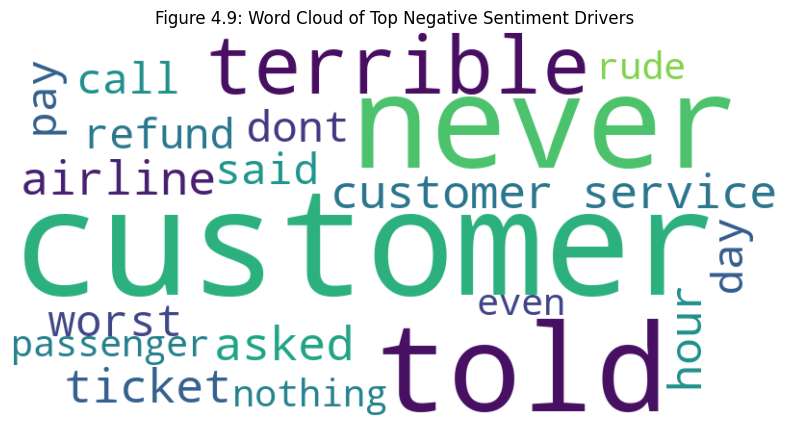

In [35]:
# --- START CELL 2: FEATURE IMPORTANCE (Chapter 4.5.1) ---
from wordcloud import WordCloud

# Get feature names from the TF-IDF Vectorizer
feature_names = tfidf.get_feature_names_out()

# Get the coefficients from the Logistic Regression model
coefficients = log_model_b.coef_[0]

# Combine features and coefficients into a DataFrame
coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefficients})
coef_df['abs_coef'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values(by='abs_coef', ascending=False)

# 1. Top Positive and Negative Features (Data for Chapter 4 Table)
top_n = 20
top_pos_features = coef_df[coef_df['coefficient'] > 0].head(top_n)
top_neg_features = coef_df[coef_df['coefficient'] < 0].head(top_n)

print("\n--- 2. Top 20 Positive Sentiment Features ---")
print(top_pos_features[['feature', 'coefficient']].sort_values(by='coefficient', ascending=False))
print("\n--- 3. Top 20 Negative Sentiment Features ---")
print(top_neg_features[['feature', 'coefficient']].sort_values(by='coefficient', ascending=True))

# 2. Word Cloud (Figure 4.9) - Focusing on High-Impact Negative Terms
negative_weights = {row['feature']: abs(row['coefficient']) for index, row in top_neg_features.iterrows()}

wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100).generate_from_frequencies(negative_weights)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Figure 4.9: Word Cloud of Top Negative Sentiment Drivers')
plt.savefig('word_cloud_negative.png')
plt.show()
# --- END CELL 2 ---

10.  ROC Curve for Binary Model

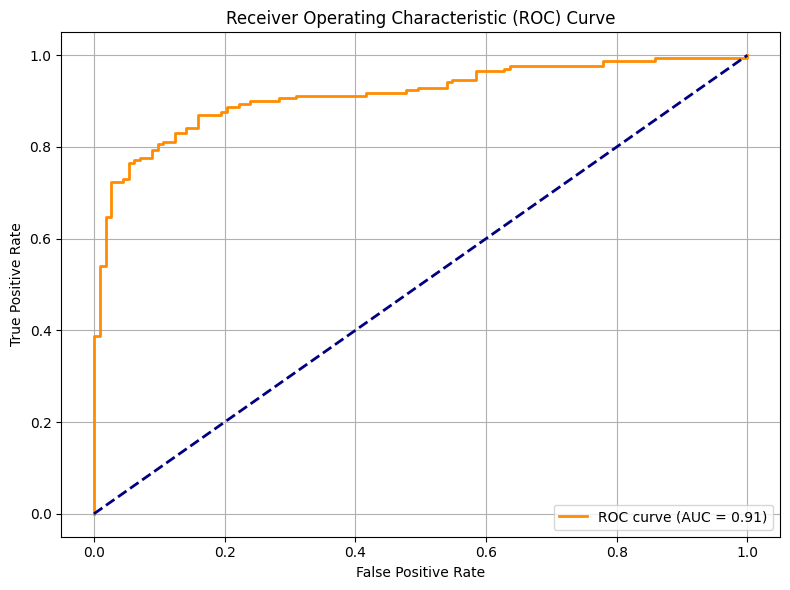

In [36]:
from sklearn.metrics import roc_curve, auc

# Calculate ROC curve and AUC for binary classification
# *** FIX: Use the optimized model here ***
y_proba = log_model_b_optimized.predict_proba(X_test_b)[:, 1] 

# Get predicted probabilities for the positive class
y_test_binary = y_test_b.map({'Negative': 0, 'Positive': 1}) # Convert sentiment labels to binary format
fpr, tpr, thresholds = roc_curve(y_test_binary, y_proba) # Calculate false positive rate, true positive rate, and thresholds
roc_auc = auc(fpr, tpr) # Calculate the area under the ROC curve

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.savefig('ROC.png')
plt.show()

11.  Feature Importance (Words Driving Sentiment)

In [37]:
feature_names = tfidf.get_feature_names_out() # Get the coefficients of the logistic regression model
coefficients = log_model_b.coef_[0] # Get the feature names from the TF-IDF vectorizer
top_pos_indices = np.argsort(coefficients)[-20:] # Get indices of top 20 positive words
top_neg_indices = np.argsort(coefficients)[:20] # Get indices of top 20 negative words
print("🔵 Top Positive Words:")
for i in top_pos_indices: # Get indices of top 20 positive words
    print(f"{feature_names[i]} ({coefficients[i]:.3f})")
print("\n🔴 Top Negative Words:")
for i in top_neg_indices: # Get indices of top 20 negative words
    print(f"{feature_names[i]} ({coefficients[i]:.3f})")

🔵 Top Positive Words:
cabin (0.892)
wifi (0.908)
really (0.911)
attentive (0.918)
professional (0.924)
nice (0.976)
efficient (1.015)
amazing (1.039)
overall (1.073)
aircraft (1.095)
ife (1.161)
food (1.226)
lounge (1.255)
entertainment (1.485)
comfortable (1.530)
great (1.658)
friendly (1.676)
crew (1.696)
excellent (2.059)
good (2.589)

🔴 Top Negative Words:
customer (-2.108)
never (-1.607)
told (-1.425)
terrible (-1.375)
customer service (-1.350)
airline (-1.338)
asked (-1.332)
ticket (-1.317)
hour (-1.226)
worst (-1.187)
pay (-1.154)
said (-1.130)
call (-1.116)
day (-1.099)
dont (-1.087)
refund (-1.033)
passenger (-1.016)
rude (-1.000)
nothing (-0.999)
even (-0.980)


12. Saving The Model And vectorizer 

In [38]:
import joblib
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
joblib.dump(log_model_b, 'logistic_model_binary.pkl')


['logistic_model_binary.pkl']

13. Geographic Distribution Map

In [39]:
# 6. Geographic Distribution of Reviews

import plotly.express as px
country_counts = df['Country'].value_counts().reset_index()
country_counts.columns = ['Country', 'Review_Count']
fig_map = px.choropleth(
    country_counts,
    locations="Country",
    locationmode='country names',
    color="Review_Count",
    hover_name="Country",
    hover_data={"Review_Count": True},
    color_continuous_scale=px.colors.sequential.Plasma,
    title="Geographic Distribution of Customer Reviews by Country"
)
fig_map.update_geos(
    showcoastlines=True, coastlinecolor="Black",
    showland=True, landcolor="lightgray",
    showocean=True, oceancolor="lightblue",
    showlakes=True, lakecolor="lightblue",
    showrivers=True, rivercolor="lightblue"
)
fig_map.update_layout(margin={"r":0,"t":50,"l":0,"b":0})
fig_map.show()
try:
    fig_map.write_image("geographic_review_map.png")
    print("Static map 'geographic_review_map.png' saved successfully.")
except Exception as e:
    print(f"Could not save static map. Ensure 'kaleido' is installed: {e}")


C:\Users\Fadi\AppData\Local\Temp\ipykernel_2764\503679681.py:6: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



Static map 'geographic_review_map.png' saved successfully.


15. Save Key Plots for Dashboard
# Average Ratings by Travel Class

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

# Average Ratings by Travel Class
if 'Travel Class' in df.columns and 'Overall Rating' in df.columns:
    plt.figure(figsize=(10, 7))
    hue_col = 'Travel Class'
    sns.barplot(data=df, x='Travel Class', y='Overall Rating', hue=hue_col, palette='mako', legend=False)
    plt.title('Average Overall Rating by Travel Class')
    plt.xlabel('Travel Class')
    plt.ylabel('Average Overall Rating')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('avg_rating_by_travel_class.png')
    plt.close()

# Average Ratings by Travel Type
if 'Travel Type' in df.columns and 'Overall Rating' in df.columns:
    plt.figure(figsize=(10, 7))
    hue_col = 'Travel Type'
    sns.barplot(data=df, x='Travel Type', y='Overall Rating', hue=hue_col, palette='crest', legend=False)
    plt.title('Average Overall Rating by Travel Type')
    plt.xlabel('Travel Type')
    plt.ylabel('Average Overall Rating')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('avg_rating_by_travel_type.png')
    plt.close()

# Distribution of Key Numerical Ratings
rating_columns_to_plot = ['Staff Service', 'Food Quality', 'Seating Comfort']
available_rating_columns = [col for col in rating_columns_to_plot if col in df.columns]
if available_rating_columns:
    plt.figure(figsize=(5 * len(available_rating_columns), 5))
    for i, col in enumerate(available_rating_columns):
        plt.subplot(1, len(available_rating_columns), i + 1)
        sns.countplot(data=df, x=col, hue=col, palette='Blues_d', legend=False)
        plt.title(f'Distribution of {col} Ratings')
        plt.xlabel(f'{col} Rating')
        plt.ylabel('Number of Reviews')
        plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('key_ratings_distribution.png')
    plt.close()

print("\nAll dashboard visualizations (PNGs) should now be generated in your notebook directory.")



All dashboard visualizations (PNGs) should now be generated in your notebook directory.


In [41]:
print("Final Model Accuracy Score:", accuracy_score(y_test_b, y_pred_b))

Final Model Accuracy Score: 0.8515901060070671


In [42]:
print("Final Model Accuracy Score:", accuracy_score(y_test_b, y_pred_b))

Final Model Accuracy Score: 0.8515901060070671


JUSTIFICATION PURPOSE 

In [43]:
# --- INSERT HYPERPARAMETER TUNING (For Chapter 3 Justification) ---
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Define the parameter search space (C and regularization type)
param_grid = {
    'C': [0.1, 1, 10, 100],  # Regularization strength
    'penalty': ['l1', 'l2']  # Type of regularization
}

# Initialize Grid Search with cross-validation (cv=5)
# Note: solver='liblinear' is required for the 'l1' penalty
grid_search = GridSearchCV(
    LogisticRegression(solver='liblinear', max_iter=200, random_state=42), 
    param_grid, 
    cv=5, 
    scoring='accuracy', 
    verbose=1
)

# Run the search on the training data
print("Starting Grid Search for Optimal Logistic Regression Parameters...")
grid_search.fit(X_train, y_train)

# Store the best parameters for the final model
best_params = grid_search.best_params_
print(f"\nOptimal Logistic Regression Parameters: {best_params}")

# Train the final model with the best parameters
sentiment_model = LogisticRegression(
    solver='liblinear', 
    max_iter=200, 
    random_state=42, 
    **best_params # Use the best C and penalty found
)

print("\nTraining Final Optimized Logistic Regression Model...")
sentiment_model.fit(X_train, y_train) 
# --- END HYPERPARAMETER TUNING AND FINAL TRAINING ---

Starting Grid Search for Optimal Logistic Regression Parameters...
Fitting 5 folds for each of 8 candidates, totalling 40 fits


c:\Users\Fadi\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning:

Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.

c:\Users\Fadi\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning:

Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.

c:\Users\Fadi\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning:

Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised 


Optimal Logistic Regression Parameters: {'C': 10, 'penalty': 'l2'}

Training Final Optimized Logistic Regression Model...


,penalty,'l2'
,dual,False
,tol,0.0001
,C,10
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'liblinear'
,max_iter,200
,multi_class,'deprecated'
